In [1]:
import pandas as pd
import zipfile

In [2]:
import zipfile
import os

zip_path = "Banana Ripeness Classification.v1i.folder.zip"
extract_path = "/content/banana_dataset"


os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [3]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 36.4 MB/s eta 0:00:00


In [4]:
data_yaml = """
train: banana_dataset/train
val: banana_dataset/valid

nc: 6
names: ['freshripe', 'freshunripe', 'overripe', 'ripe', 'rotten', 'unripe']
"""

with open('banana_dataset/data.yaml', 'w') as f:
    f.write(data_yaml)

In [13]:
from ultralytics import YOLO

model = YOLO('yolov8n-cls.pt')
model.train(data='/content/banana_dataset', epochs=30, imgsz=320, batch=4)


Ultralytics 8.3.213 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/banana_dataset, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x77fae6f58e90>
curves: []
curves_results: []
fitness: 0.9933214485645294
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.9866428971290588, 'metrics/accuracy_top5': 1.0, 'fitness': 0.9933214485645294}
save_dir: PosixPath('/content/runs/classify/train4')
speed: {'preprocess': 0.19197186108507, 'inference': 1.485387907390045, 'loss': 0.0014461985736655548, 'postprocess': 0.0018613659886664077}
task: 'classify'
top1: 0.9866428971290588
top5: 1.0


image 1/1 /content/banana_dataset/test/freshunripe/musa-acuminata-freshunripe-1cdf07a1-2653-11ec-a4b4-d8c4975e38aa_jpg.rf.555b6a78669a85820d8f2e1b63332fdc.jpg: 320x320 freshunripe 1.00, freshripe 0.00, rotten 0.00, unripe 0.00, overripe 0.00, 4.6ms
Speed: 13.9ms preprocess, 4.6ms inference, 0.1ms postprocess per image at shape (1, 3, 320, 320)


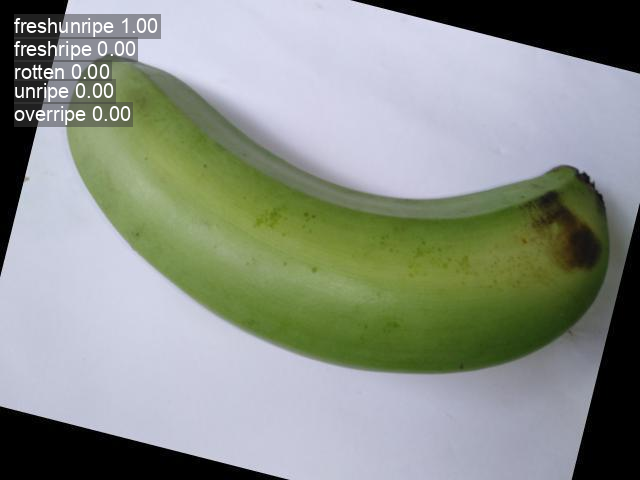

Classe prevista: freshunripe (99.99%)


In [17]:
from ultralytics import YOLO


model = YOLO('/content/runs/classify/train/weights/best.pt')


img_path = '/content/banana_dataset/test/freshunripe/musa-acuminata-freshunripe-1cdf07a1-2653-11ec-a4b4-d8c4975e38aa_jpg.rf.555b6a78669a85820d8f2e1b63332fdc.jpg'
results= model(img_path)
results[0].show()
probs = results[0].probs
class_id = probs.top1
confidence = probs.top1conf.item() * 100
class_name = results[0].names[class_id]

print(f"Classe prevista: {class_name} ({confidence:.2f}%)")
